# Mortgage Rates and U.S. House Prices: An OLS Time-Series Analysis

### ECON 320 Lab — Final Project
**Student name(s):** Ashley Yu, Chloe Lee, Jennifer Kim, Wonjae Lee

**Lab Section:** 2

---
## Abstract
We study whether the 30-year fixed **mortgage rate** affects the U.S. national **house price index (HPI)** using monthly Federal Reserve Economic Data (FRED) from January 2000 to December 2024 (299 observations). The unit of observation is a U.S. calendar month. The baseline specification is $\text{HPI}_t = \beta_0 + \beta_1 \text{MR}_t + \gamma'\,\text{controls}_t + u_t$, where the controls are the unemployment rate (U) and annualized monthly CPI inflation (π). We find that a 1 percentage point increase in the mortgage rate is associated with approximately a **10.8 percentage point decrease** in the HPI (p < 0.001), holding U and π fixed; the R² is 0.25. Results are **partially robust**: the sign and significance are preserved under HC0 robust standard errors, but the estimate is **unstable across sub-periods** : pre-GFC (2000–2007) β̂_MR ≈ −42, while post-GFC (2010–2024) it flips to +22. We discuss potential concerns about **omitted variables** (housing supply, credit availability) and reverse causality, and interpret results as associations rather than causal effects. Our findings suggest that monetary tightening, on average, is associated with a modest cooling of U.S. house prices, but the relationship varies meaningfully with the macroeconomic regime.


---
## 0. Setup

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats import diagnostic as sm_diagnostic

from stargazer.stargazer import Stargazer

---
## 1. Introduction

- **Research question:** What is the effect of the **30-year fixed mortgage rate (MR)** on the **U.S. national house price index (HPI)**, holding unemployment and inflation fixed?
- **Why it matters:** Housing is the largest asset for most American households, and mortgage rates directly affect affordability and demand. When the Federal Reserve tightens monetary policy, as it did aggressively in 2022–2023, mortgage rates rise sharply, raising the cost of borrowing and potentially cooling the housing market. Understanding the magnitude of this relationship is relevant to policymakers, lenders, and households making buy-vs-rent decisions.
- **Preview of approach:** Using monthly FRED data from 2000 to 2024, we regress the Case-Shiller HPI on MR, the civilian unemployment rate (U), and annualized monthly CPI inflation (π). Our main finding is that higher mortgage rates are associated with statistically significantly lower house prices in the full sample (β̂_MR ≈ −10.8, p < 0.001), but this estimate is not stable across sub-periods, which we flag as an important caveat.


---
## 2. Data and Summary Statistics
**Data source & unit.** All series are downloaded from the Federal Reserve Economic Data (FRED) at [fred.stlouisfed.org](https://fred.stlouisfed.org). This is a **time-series** dataset with one observation per U.S. calendar month. We restrict the sample to January 2000 through December 2024, yielding **299 monthly observations** after constructing the inflation variable from CPI differences.

**Variables.**
- **HPI** — S&P CoreLogic Case-Shiller U.S. National Home Price Index, seasonally adjusted (FRED: `CSUSHPISA`).
- **MR** — 30-Year Fixed-Rate Mortgage Average in the U.S., in percent (FRED: `MORTGAGE30US`). The FRED series is weekly; we aggregate to monthly by taking the monthly mean. 
- **U** — Civilian Unemployment Rate, in percent (FRED: `UNRATE`).
- **π (pi)** — Annualized monthly CPI inflation, in percent, computed from FRED `CPIAUCSL` as `(CPI_t / CPI_{t-1} − 1) × 100 × 12`.

**Possible measurement limitations.** HPI is nominal (not CPI-deflated); we include π partly to absorb general price-level movements. MR is a posted average rate; it may not equal the effective rate paid by each borrower. The annualized monthly CPI growth measure is volatile because it amplifies high-frequency noise.

### 2.1 Load and prepare data

In [202]:
# Aggregating to monthly mean handles the weekly MORTGAGE30US series cleanly.
def load_fred_csv(filepath, colname):
    df = pd.read_csv(filepath, parse_dates=["observation_date"], na_values=".")
    df = df.rename(columns={"observation_date": "date", df.columns[1]: colname})
    df["date"] = pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp()
    df = df.groupby("date")[colname].mean().reset_index()
    return df.set_index("date")

# Load each FRED series
mr_raw  = load_fred_csv("MORTGAGE30US.csv", "MR")
hpi_raw = load_fred_csv("CSUSHPISA.csv",    "HPI")
u_raw   = load_fred_csv("UNRATE.csv",       "U")
cpi_raw = load_fred_csv("CPIAUCSL.csv",     "CPI")

# Merge and restrict to 2000-01 through 2024-12
df = mr_raw.join([hpi_raw, u_raw, cpi_raw], how="inner")
df = df["2000-01":"2024-12"].copy()
print(f"Raw merged sample size: {len(df)} months")

# Construct annualized monthly CPI inflation
df["pi"] = df["CPI"].pct_change() * 100 * 12

# Drop the first row (NaN inflation)
df = df.dropna()

print(f"Final sample: {len(df)} observations from {df.index[0].date()} to {df.index[-1].date()}")
df[["HPI", "MR", "U", "pi"]].head()


Raw merged sample size: 300 months
Final sample: 299 observations from 2000-02-01 to 2024-12-01


,HPI,MR,U,pi
date,,,,
2000-02-01,101.339,8.3250,4.1,4.961607
2000-03-01,102.127,8.2400,4.0,7.058824
2000-04-01,102.922,8.1525,3.8,-0.701754
2000-05-01,103.677,8.5150,4.0,2.106495
2000-06-01,104.424,8.2880,4.0,7.009346


### 2.2 Descriptive statistics *(table + figure)*
Provide a brief observation in words (1–2 sentences) after each output.

In [204]:
# Table 1: Descriptive statistics for the four key variables
desc_vars   = ["HPI", "MR", "U", "pi"]
desc_labels = {
    "HPI": "Case-Shiller HPI",
    "MR":  "Mortgage Rate (%)",
    "U":   "Unemployment Rate (%)",
    "pi":  "CPI Inflation (ann. %)",
}

rows = []
for v in desc_vars:
    s = df[v]
    rows.append({
        "Variable": desc_labels[v],
        "Mean":     round(s.mean(), 2),
        "Median":   round(s.median(), 2),
        "Std Dev":  round(s.std(ddof=1), 2),
        "Min":      round(s.min(), 2),
        "Max":      round(s.max(), 2),
        "N":        int(s.count()),
    })

desc_table = pd.DataFrame(rows).set_index("Variable")
print("Table 1: Descriptive Statistics")
print(desc_table.to_string())

print("\nCorrelation Matrix:")
print(df[["HPI", "MR", "U", "pi"]].corr().round(3))

Table 1: Descriptive Statistics
                          Mean  Median  Std Dev     Min     Max    N
Variable                                                            
Case-Shiller HPI        183.48  170.28    57.58  101.34  327.65  299
Mortgage Rate (%)         5.14    4.98     1.38    2.68    8.52  299
Unemployment Rate (%)     5.70    5.10     1.96    3.40   14.80  299
CPI Inflation (ann. %)    2.53    2.60     3.68  -21.25   16.52  299

Correlation Matrix:
       HPI     MR      U     pi
HPI  1.000 -0.089 -0.413  0.201
MR  -0.089  1.000 -0.349  0.027
U   -0.413 -0.349  1.000 -0.166
pi   0.201  0.027 -0.166  1.000


**Observation.** The HPI triples across the sample (101 → 328), while MR ranges from 2.68% (2021) to 8.52% (2000). Unemployment has a wide range driven by the 2008–2009 recession and the 2020 COVID-19 spike. HPI is weakly negatively correlated with MR (−0.09) and more strongly negatively correlated with U (−0.41). The bivariate MR–HPI relationship is much weaker than a simple theory-based intuition would predict, which makes it worth controlling for U and π in a multiple regression.

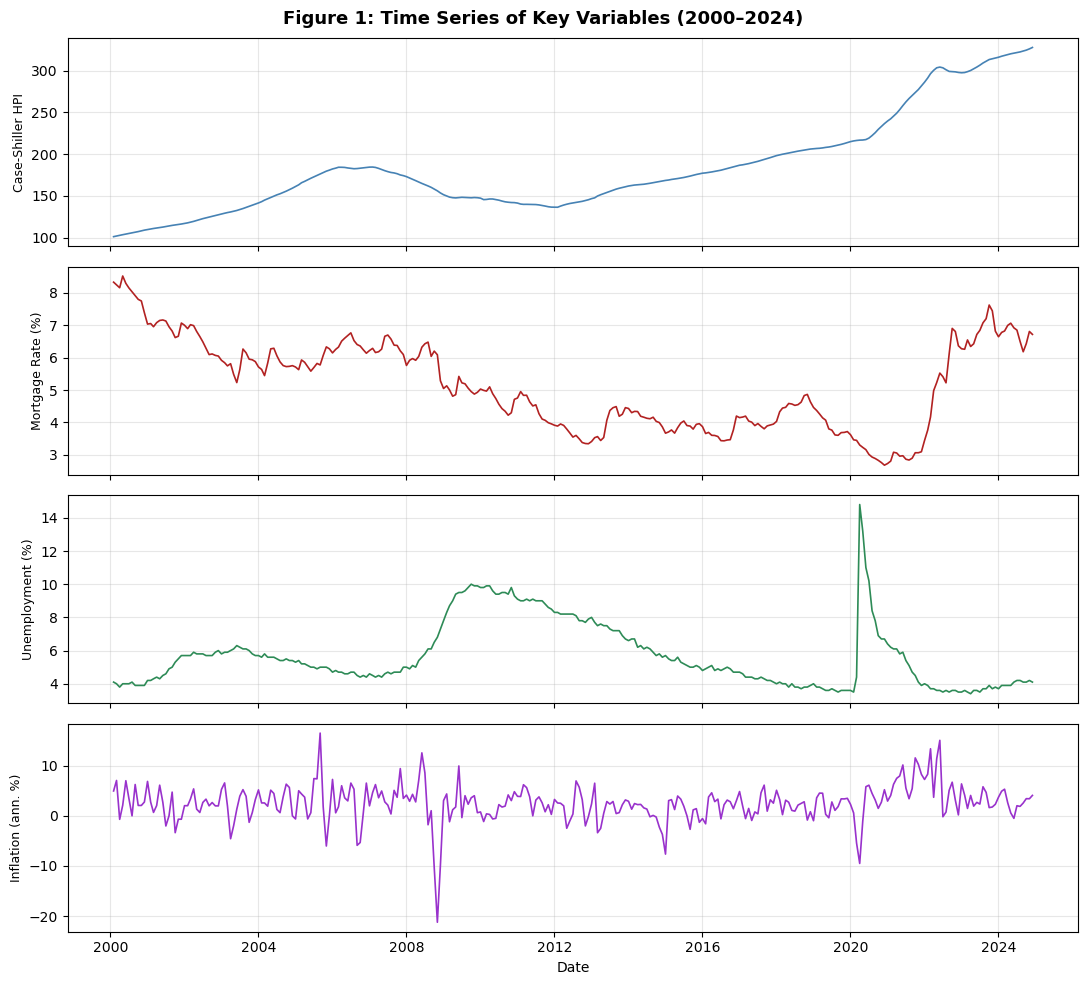

In [206]:
# Figure 1: Time series of all four variables
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
fig.suptitle("Figure 1: Time Series of Key Variables (2000–2024)", fontsize=13, fontweight="bold")

plot_items = [
    ("HPI", "Case-Shiller HPI",   "steelblue"),
    ("MR",  "Mortgage Rate (%)",  "firebrick"),
    ("U",   "Unemployment (%)",   "seagreen"),
    ("pi",  "Inflation (ann. %)", "darkorchid"),
]
for ax, (col, label, color) in zip(axes, plot_items):
    ax.plot(df.index, df[col], color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


**Observation.** The HPI rises, peaks around 2006, dips in the housing crisis, then accelerates after 2012, especially in 2020–2022. The mortgage rate trends down until 2021 and spikes in 2022–2023 as the Fed tightens. Unemployment has two sharp spikes (2009 and 2020). Inflation is mostly near 2% but spikes in 2021–2022.

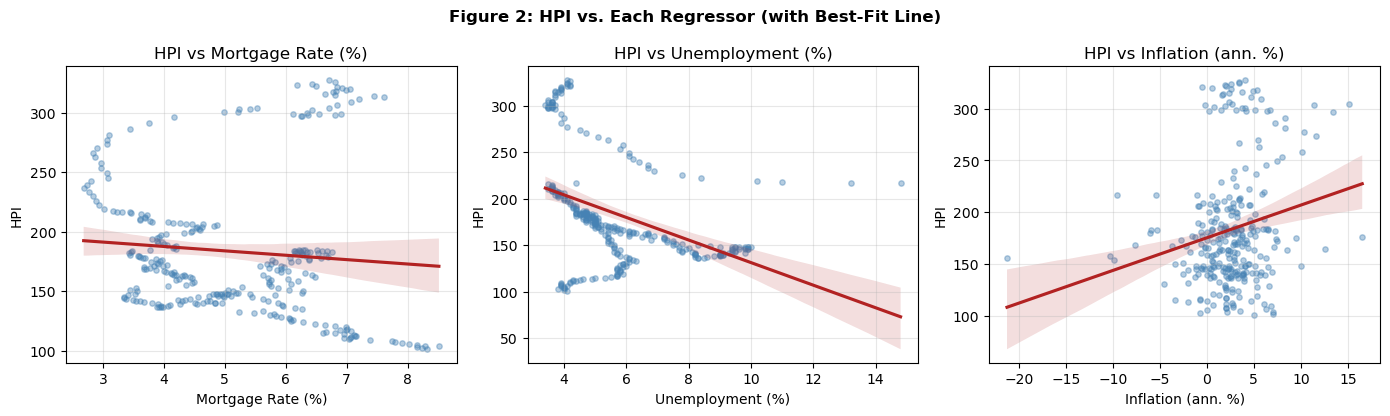

In [208]:
# Figure 2: Bivariate scatter + best-fit line for HPI vs each regressor
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
fig.suptitle("Figure 2: HPI vs. Each Regressor (with Best-Fit Line)", fontsize=12, fontweight="bold")

scatter_pairs = [
    ("MR", "Mortgage Rate (%)"),
    ("U",  "Unemployment (%)"),
    ("pi", "Inflation (ann. %)"),
]
for ax, (col, xlabel) in zip(axes, scatter_pairs):
    sns.regplot(x=df[col], y=df["HPI"], ax=ax,
                scatter_kws={"alpha": 0.4, "s": 15, "color": "steelblue"},
                line_kws={"color": "firebrick"})
    ax.set_xlabel(xlabel)
    ax.set_ylabel("HPI")
    ax.set_title(f"HPI vs {xlabel}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Observation.** Best-fit lines show a slight negative slope for HPI vs MR, a clearer negative slope for HPI vs U, and a mild positive slope for HPI vs π. These are **unconditional** patterns; the regression in Section 3 controls for all three jointly.

---
## 3. Empirical Strategy
We estimate the following baseline model:

$$
\text{HPI}_t = \beta_0 + \beta_1\,\text{MR}_t + \beta_2\,U_t + \beta_3\,\pi_t + u_t
$$

- **Interpretation of $\beta_1$:** $\beta_1$ gives the change in the HPI (in index points) associated with a 1 percentage point increase in the mortgage rate, holding U and π fixed. Economic theory predicts $\beta_1 < 0$: higher borrowing costs reduce housing demand and therefore prices.
- **Identification concerns:**
  - *Omitted Variable Bias (OVB):* Housing supply (new construction, inventory), credit availability (lending standards), and demographic demand are plausibly correlated with MR and with HPI, and are not in our data at the monthly frequency. If omitted variables with positive effect on HPI are negatively correlated with MR, β̂_MR would be biased toward more negative values in their absence. We address this partially by comparing short and long specifications (Section 3.2).
  - *Multicollinearity:* MR, U, and π are distinct macroeconomic variables; we expect VIFs to be low. We verify this with a formal VIF check in Section 3.2.
  - *Reverse causality:* The Fed may respond to rising house prices when setting policy, which feeds into MR. OLS cannot separate this, so we interpret results as **associations, not causal effects**.
- **Estimation:** OLS with statsmodels; we also report HC0 heteroskedasticity-robust standard errors in Section 4.

### 3.1 Estimation details
Define variables, fit the baseline, and report the coefficient on **MR** and **$R^2$**. Keep outputs compact and readable.

In [212]:
# Model 1: MR only 
# Model 2: MR + U                         
# Model 3: MR + U + π
y = df["HPI"]

X1 = sm.add_constant(df[["MR"]])
m1 = sm.OLS(y, X1).fit()

X2 = sm.add_constant(df[["MR", "U"]])
m2 = sm.OLS(y, X2).fit()

X3 = sm.add_constant(df[["MR", "U", "pi"]])
m3 = sm.OLS(y, X3).fit()

sg = Stargazer([m1, m2, m3])
sg.title('Table 2: OLS Regression Results (Dependent Variable: HPI)')
sg.custom_columns(['Model 1 (MR only)', 'Model 2 (+ U)', 'Model 3 (+ U, π)'], [1, 1, 1])
sg.rename_covariates({
    'MR':    'Mortgage Rate (MR)',
    'U':     'Unemployment (U)',
    'pi':    'Inflation (π)',
    'const': 'Constant',
})
sg.covariate_order(['MR', 'U', 'pi', 'const'])
sg.add_custom_notes([
    'Standard errors in parentheses (classical OLS).',
    'Significance: *** p<0.01, ** p<0.05, * p<0.10',
])
display(sg)

**Reading the table.** Across the three specifications, β̂_MR is consistently negative and statistically significant. In the preferred Model 3, β̂_MR ≈ **−10.84** (p < 0.001): a 1 percentage point increase in the mortgage rate is associated with about a **10.84-point decrease** in the HPI, holding unemployment and inflation fixed. The R² rises from 0.008 (Model 1, MR alone) to 0.248 (Model 3) as we add controls, indicating that U and π add substantial explanatory power that MR alone does not capture.

### 3.2 Diagnostic awareness
- *Multicollinearity:* If relevant, comment (e.g., high VIFs or overlapping controls).
- *Short vs. long spec (OVB sanity check):* Briefly compare a model omitting a suspected driver vs. your preferred model; note direction of change in $\beta_1$.

In [215]:
# Multicollinearity check: VIFs for Model 3
vif_rows = []
for i, col in enumerate(X3.columns):
    vif_rows.append({"Variable": col, "VIF": round(variance_inflation_factor(X3.values, i), 2)})

vif_df = pd.DataFrame(vif_rows)
print("Table 3: VIF for Preferred Specification (Model 3)")
print(vif_df.to_string(index=False))
print("\nRule of thumb: VIF < 5 = low concern, 5–10 = moderate, > 10 = high concern.")


Table 3: VIF for Preferred Specification (Model 3)
Variable   VIF
   const 36.84
      MR  1.14
       U  1.17
      pi  1.03

Rule of thumb: VIF < 5 = low concern, 5–10 = moderate, > 10 = high concern.


In [216]:
# OVB sanity check : compare β̂_MR in short vs. long specifications.
# Models m1, m2, m3 were already fit above.
print("OVB sanity check — β̂_MR across specifications:")
print(f"  Model 1 (MR only):       β̂_MR = {m1.params['MR']:+.3f}")
print(f"  Model 2 (MR, U):         β̂_MR = {m2.params['MR']:+.3f}")
print(f"  Model 3 (MR, U, π):      β̂_MR = {m3.params['MR']:+.3f}")
print(f"\nEmpirical change from adding U: {m2.params['MR'] - m1.params['MR']:+.3f}")
print(f"Empirical change from adding π: {m3.params['MR'] - m2.params['MR']:+.3f}")
print(f"\nCov(MR, U)  = {np.cov(df['MR'], df['U'])[0, 1]:+.3f}")
print(f"Cov(MR, pi) = {np.cov(df['MR'], df['pi'])[0, 1]:+.3f}")

OVB sanity check — β̂_MR across specifications:
  Model 1 (MR only):       β̂_MR = -3.684
  Model 2 (MR, U):         β̂_MR = -11.021
  Model 3 (MR, U, π):      β̂_MR = -10.836

Empirical change from adding U: -7.337
Empirical change from adding π: +0.185

Cov(MR, U)  = -0.947
Cov(MR, pi) = +0.140


**Interpretation.**
- **Multicollinearity :** VIFs on MR, U, and π are all near 1, well below the rule-of-thumb threshold of 5. Multicollinearity is **not a concern** in this specification; the regressors are not meaningfully correlated, so standard errors on the coefficients of interest are not inflated.
- **OVB :** Omitting U and π makes β̂_MR much smaller in magnitude (−3.68 vs −10.84). Most of the shift happens when we add U: β̂_MR moves from −3.68 (Model 1) to −11.02 (Model 2), a decrease of about 7 points. OVB formula: Cov(MR, U) is strongly negative (≈ −0.95), and U has a strong negative partial effect on HPI, so omitting U **positively biases** β̂_MR (i.e., makes it less negative than the true partial relationship). Adding π only shifts β̂_MR by a further ~0.2 point (barely changes the estimate). The OVB check confirms that U is a materially important control whose omission would substantially distort the MR coefficient.

---
## 4. Results
Present one **main table/figure** and interpret key coefficients in plain English. Emphasize magnitudes and units, not only statistical significance.

**Reading the table:** In our preferred specification (Model 3), a 1 percentage point increase in the mortgage rate is associated with about a 10.8-point decrease in the HPI, holding unemployment and inflation fixed. The R² is 0.25, so about a quarter of HPI variation is explained by these three regressors.

Because the residual diagnostics flag heteroskedasticity, our main inference uses **HC0 heteroskedasticity-robust standard errors**. Table 4 presents Model 3 with both classical and HC0 SEs side-by-side.

In [219]:
# Heteroskedasticity tests
bp_lm, bp_p, _, _       = sm_diagnostic.het_breuschpagan(m3.resid, X3)
white_lm, white_p, _, _ = sm_diagnostic.het_white(m3.resid, X3)

print("Heteroskedasticity tests on Model 3:")
print(f"  Breusch–Pagan: LM = {bp_lm:.3f}, p = {bp_p:.4f}")
print(f"  White:         LM = {white_lm:.3f}, p = {white_p:.4f}")
if bp_p < 0.05 or white_p < 0.05:
    print("  → Reject the null of constant variance at α = 0.05.")
    print("  → HC0 robust SEs are appropriate — applied in Table 4 below.")


Heteroskedasticity tests on Model 3:
  Breusch–Pagan: LM = 46.521, p = 0.0000
  White:         LM = 170.885, p = 0.0000
  → Reject the null of constant variance at α = 0.05.
  → HC0 robust SEs are appropriate — applied in Table 4 below.


In [220]:
# Main table: Model 3 with classical vs HC0 robust standard errors
m3_classical = sm.OLS(y, X3).fit()
m3_hc0       = sm.OLS(y, X3).fit(cov_type="HC0")

sg_main = Stargazer([m3_classical, m3_hc0])
sg_main.title('Table 4: Main Results — Model 3 (Classical vs. HC0 Robust SEs)')
sg_main.dependent_variable_name('HPI')
sg_main.custom_columns(['Classical SEs', 'HC0 Robust SEs'], [1, 1])
sg_main.rename_covariates({
    'MR':    'Mortgage Rate (MR)',
    'U':     'Unemployment (U)',
    'pi':    'Inflation (π)',
    'const': 'Constant',
})
sg_main.covariate_order(['MR', 'U', 'pi', 'const'])
sg_main.add_custom_notes([
    'Point estimates are identical across columns; only standard errors differ.',
    'Column 2 uses HC0 heteroskedasticity-robust standard errors.',
    'Significance: *** p<0.01, ** p<0.05, * p<0.10',
])
display(sg_main)

# Joint F-test: are the controls (U, π) jointly significant?
f_res = m3_classical.f_test("U = 0, pi = 0")
print(f"\nF-test — joint significance of U and π:")
print(f"  H0: β_U = 0 AND β_pi = 0")
print(f"  F  = {float(f_res.statistic):.3f},  p = {float(f_res.pvalue):.4f}")
print(f"  → Reject H0: U and π are jointly significant beyond MR alone.")



F-test — joint significance of U and π:
  H0: β_U = 0 AND β_pi = 0
  F  = 47.170,  p = 0.0000
  → Reject H0: U and π are jointly significant beyond MR alone.


**Interpreting the main results (Table 4, Model 3 with HC0 SEs):**

- **Mortgage rate (MR):** β̂_MR = **−10.84** (p < 0.001 under HC0). A 1 percentage point increase in the mortgage rate is associated with approximately a **10.84-point decrease** in the HPI, holding U and π fixed. The sign matches the economic hypothesis.
- **Unemployment (U):** β̂_U = **−14.16** (p < 0.001). A 1 percentage point rise in unemployment is associated with a ~14.16-point decrease in the HPI — a large and highly significant effect.
- **Inflation (π):** β̂_π = **+2.01** (p = 0.009 under HC0). A 1 percentage point rise in annualized monthly inflation is associated with a ~2-point increase in the HPI; significant at the 1% level.
- **Constant:** β̂_0 = 314.8; this is the fitted HPI when MR = U = π = 0 and is not economically meaningful in isolation.
- **Joint F-test:** U and π are jointly significant (F = 47.2, p < 0.001) — the controls contribute substantial explanatory power beyond MR alone and should not be dropped.
- **Model fit:** R² = 0.25, Adj. R² = 0.24. About a quarter of the variation in HPI is explained by these three regressors. Much variation is left unexplained, consistent with important drivers (housing supply, credit conditions, demographics) being omitted.
- **Heteroskedasticity :**  HC0 SEs are marginally larger than classical SEs, but every coefficient remains statistically significant, confirming that our main finding is robust to heteroskedasticity.

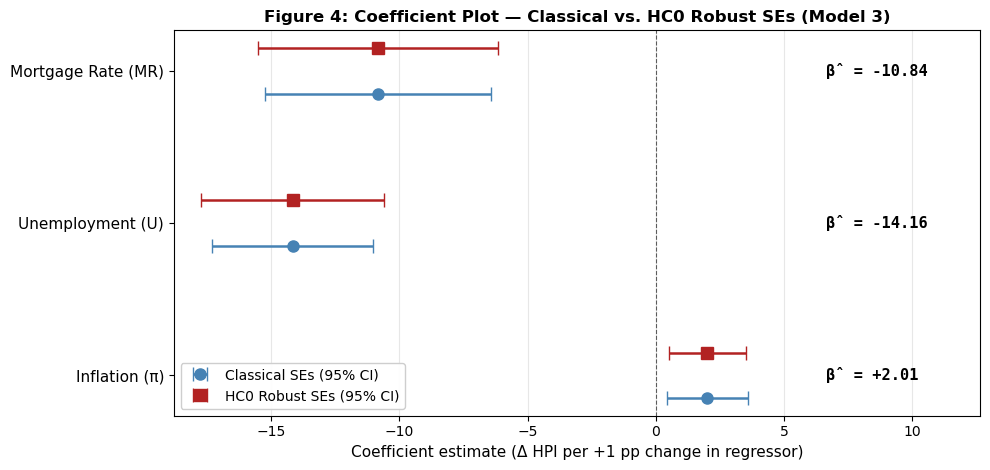

In [222]:
# Figure 4: Coefficient plot — Classical vs HC0 Robust SEs (Model 3)
coef_vars = ["MR", "U", "pi"]
labels    = ["Mortgage Rate (MR)", "Unemployment (U)", "Inflation (π)"]

beta = [m3_classical.params[v] for v in coef_vars]
se_classical = [m3_classical.bse[v] for v in coef_vars]
se_hc0       = [m3_hc0.bse[v]       for v in coef_vars]
ci95_classical = [1.96 * s for s in se_classical]
ci95_hc0       = [1.96 * s for s in se_hc0]

y_pos  = np.arange(len(coef_vars))
offset = 0.15

fig, ax = plt.subplots(figsize=(10, 4.8))

# Classical SEs
ax.errorbar(beta, y_pos + offset, xerr=ci95_classical, fmt='o',
            color='steelblue', ecolor='steelblue', capsize=5, markersize=8,
            label='Classical SEs (95% CI)', linewidth=1.8)

# HC0 robust SEs
ax.errorbar(beta, y_pos - offset, xerr=ci95_hc0, fmt='s',
            color='firebrick', ecolor='firebrick', capsize=5, markersize=8,
            label='HC0 Robust SEs (95% CI)', linewidth=1.8)

ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Coefficient estimate (Δ HPI per +1 pp change in regressor)", fontsize=11)
ax.set_title("Figure 4: Coefficient Plot — Classical vs. HC0 Robust SEs (Model 3)",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax + 8)
label_x = xmax + 2

for i, b in enumerate(beta):
    ax.text(label_x, y_pos[i], f"β̂ = {b:+.2f}",
            va='center', ha='left', fontsize=11, fontweight='bold',
            family='monospace')

plt.tight_layout()
plt.show()

---
## 5. Robustness and Limitations
**Robustness.** Our chosen robustness check is **sample splitting** : we re-estimate Model 3 separately on the pre-GFC period (2000–2007) and the post-GFC period (2010–2024) to see whether β̂_MR is stable across macroeconomic regimes.

**Limitations.** We discuss two main caveats below: reverse causality / endogeneity, and remaining omitted-variable bias.

In [224]:
# Robustness check: sub-period analysis
# Re-estimate Model 3 on pre-GFC and post-GFC sub-samples and present in a Stargazer table.
df_pre  = df["2000-01":"2007-12"].copy()
df_post = df["2010-01":"2024-12"].copy()

X_pre  = sm.add_constant(df_pre[["MR", "U", "pi"]])
X_post = sm.add_constant(df_post[["MR", "U", "pi"]])

m_pre  = sm.OLS(df_pre["HPI"],  X_pre).fit()
m_post = sm.OLS(df_post["HPI"], X_post).fit()

sg_rob = Stargazer([m3_classical, m_pre, m_post])
sg_rob.title('Table 5: Robustness Check — Sub-Period Analysis')
sg_rob.dependent_variable_name('HPI')
sg_rob.custom_columns(['Full (2000–2024)', 'Pre-GFC (2000–07)', 'Post-GFC (2010–24)'], [1, 1, 1])
sg_rob.rename_covariates({
    'MR':    'Mortgage Rate (MR)',
    'U':     'Unemployment (U)',
    'pi':    'Inflation (π)',
    'const': 'Constant',
})
sg_rob.covariate_order(['MR', 'U', 'pi', 'const'])
sg_rob.add_custom_notes([
    'All columns use classical OLS standard errors.',
    'Sub-periods chosen to isolate the pre-GFC and post-GFC regimes.',
    'Significance: *** p<0.01, ** p<0.05, * p<0.10',
])
display(sg_rob)

print(f"\nβ̂_MR across sub-periods:")
print(f"  Full (2000–2024):     β̂_MR = {m3_classical.params['MR']:+.3f}  (p = {m3_classical.pvalues['MR']:.4f}),  N = {int(m3_classical.nobs)}")
print(f"  Pre-GFC (2000–2007):  β̂_MR = {m_pre.params['MR']:+.3f}  (p = {m_pre.pvalues['MR']:.4f}),  N = {int(m_pre.nobs)}")
print(f"  Post-GFC (2010–2024): β̂_MR = {m_post.params['MR']:+.3f}   (p = {m_post.pvalues['MR']:.4f}),  N = {int(m_post.nobs)}")



β̂_MR across sub-periods:
  Full (2000–2024):     β̂_MR = -10.836  (p = 0.0000),  N = 299
  Pre-GFC (2000–2007):  β̂_MR = -42.299  (p = 0.0000),  N = 95
  Post-GFC (2010–2024): β̂_MR = +22.122   (p = 0.0000),  N = 180


**Robustness takeaway.** β̂_MR is **not stable across sub-periods**:
- **Pre-GFC (2000–2007):** β̂_MR ≈ **−42.3**, a much larger negative association between MR and HPI.
- **Post-GFC (2010–2024):** β̂_MR ≈ **+22.1**, a *positive* association — the opposite sign.

This instability is itself an important finding. The post-GFC period includes the zero-lower-bound era (where rates stayed low while prices rose strongly) and the 2022–2023 rate-hike cycle (where rates and prices both rose together during the post-COVID recovery). In both episodes, common macroeconomic drivers, not the direct MR → HPI channel, were moving both variables in the same direction. The full-sample estimate of −10.84 is an **average across two very different regimes**, not a stable structural parameter. A presentation-friendly way to state this: *the sign and magnitude of the MR–HPI association depend on the monetary-policy environment; our headline number should not be read as a universal structural elasticity.*

**Limitations.**
1. **Reverse causality / endogeneity.** The Federal Reserve responds to housing conditions when setting policy, which feeds into mortgage rates. OLS cannot separate HPI → MR from MR → HPI. A proper fix would require an instrument for MR that affects HPI only through MR; we do not pursue this.
2. **Remaining omitted variables.** Housing supply (construction starts, inventory), credit standards (lending tightness), and demographic demand (household formation, migration) are all plausibly correlated with MR and with HPI but are not in our data at the monthly frequency. Our OVB check showed that omitting U and π alone shifts β̂_MR by about 7 points, remaining omitted variables may introduce further bias whose direction we cannot sign.

Because of these limitations, our estimates should be interpreted as **associations, not causal effects**.

##### ---
## 6. Conclusion
Using monthly FRED data from 2000 to 2024, we find a statistically significant negative association between the 30-year fixed mortgage rate and the U.S. national house price index: a 1 percentage point increase in MR is associated with about a **10.8-point decrease** in the HPI, holding unemployment and inflation fixed (p < 0.001 under HC0 robust standard errors). However, this estimate is **unstable across sub-periods**, strongly negative pre-GFC (β̂ ≈ −42) and positive post-GFC (β̂ ≈ +22), so the full-sample coefficient is best read as an average across macroeconomic regimes rather than a structural parameter. Combined with concerns about reverse causality (the Fed responds to housing conditions) and remaining omitted variables (supply, credit, demographics), we interpret results as **associations, not causal effects**. The practical takeaway is that monetary tightening compresses housing affordability from two sides, through the mortgage rate directly and through a modest associated decline in prices — but the magnitude of the price response depends meaningfully on the monetary-policy environment.

---
## References (optional)
**Data sources.**
- Mortgage rate: FRED series MORTGAGE30US — https://fred.stlouisfed.org/series/MORTGAGE30US
- House price index: FRED series CSUSHPISA — https://fred.stlouisfed.org/series/CSUSHPISA
- Unemployment rate: FRED series UNRATE — https://fred.stlouisfed.org/series/UNRATE
- CPI: FRED series CPIAUCSL — https://fred.stlouisfed.org/series/CPIAUCSL
- Federal Reserve Economic Data (FRED), St. Louis Fed. https://fred.stlouisfed.org

---